In [1]:
# install tensorflow and pandas
import os
# os.system('pip install tensorflow pandas')
# import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# load the csv data from ../data/brainrot.csv there are no headers in the csv file
data_news = pd.read_csv('../data/newsphone.csv', header=None)
data_nophone = pd.read_csv('../data/nophone.csv', header=None)
data_brainrot = pd.read_csv('../data/brainrotphone.csv', header=None)


# Drop the NaN rows from both dataframes and remove the column names
data_news = data_news.dropna()
data_nophone = data_nophone.dropna()
data_brainrot = data_brainrot.dropna()

# combine the two dataframes into one dataframe such that there are 70 columns and n rows
data = pd.concat([data_nophone, data_news, data_brainrot], axis=0, ignore_index=True)

# Only use the last 6 columns of the dataframe
# data = data.iloc[:, 56:]

labels_news = np.ones(len(data_news))
labels_nophone = np.zeros(len(data_nophone))
labels_brainrot = np.full(len(data_brainrot), 2)
labels = np.concatenate([labels_nophone, labels_news, labels_brainrot])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

In [3]:
clf = svm.SVC(kernel='linear', C = 0.2)
clf.fit(X_train, y_train)

,C,0.2
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [4]:
# Make predictions
y_pred = clf.predict(X_test)
# Evaluate the model
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1591   57   41]
 [  88 1353  181]
 [  80  222 1160]]
              precision    recall  f1-score   support

         0.0       0.90      0.94      0.92      1689
         1.0       0.83      0.83      0.83      1622
         2.0       0.84      0.79      0.82      1462

    accuracy                           0.86      4773
   macro avg       0.86      0.86      0.86      4773
weighted avg       0.86      0.86      0.86      4773



Feature: 0, Score: 0.01802716647989655
Feature: 1, Score: -0.1121864164579165
Feature: 2, Score: -0.09376657524762777
Feature: 3, Score: -0.10890818499910893
Feature: 4, Score: 0.13022317488503177
Feature: 5, Score: -0.1953577884837614
Feature: 6, Score: 0.1251103775653064
Feature: 7, Score: 0.1359139603382573
Feature: 8, Score: 0.0745483700470686
Feature: 9, Score: -0.21750940907395488
Feature: 10, Score: 0.117551414767604
Feature: 11, Score: 0.027645468040645937
Feature: 12, Score: -0.11280651166384814
Feature: 13, Score: -0.0626891993119898
Feature: 14, Score: 0.17566324429230917
Feature: 15, Score: -0.3082360169300955
Feature: 16, Score: 0.12172863107343801
Feature: 17, Score: 0.05075325824805077
Feature: 18, Score: -0.22786289225859946
Feature: 19, Score: -0.05391129409190398
Feature: 20, Score: -0.15607157062049737
Feature: 21, Score: 0.09184486169374395
Feature: 22, Score: -0.12643297306613022
Feature: 23, Score: 0.36911239700521037
Feature: 24, Score: 0.049765020125505544
Featu

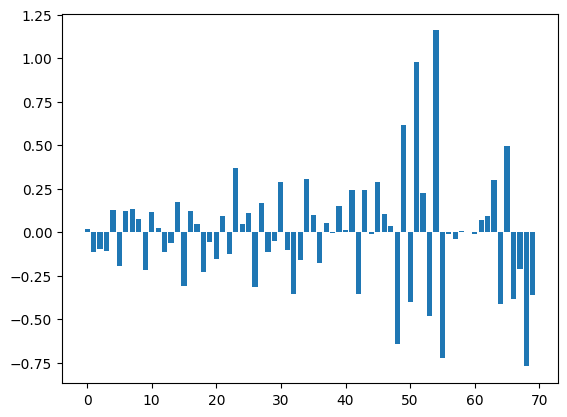

In [5]:
# show which features are most important
importance = clf.coef_[0]
for i, v in enumerate(importance):
    print(f'Feature: {i}, Score: {v}')

# plot the feature importance
import matplotlib.pyplot as plt
plt.bar([i for i in range(len(importance))], importance)
plt.show()

# # Remove all features with importance of more than |0.5|
# threshold = 0.5
# important_features = [i for i, v in enumerate(importance) if abs(v) > threshold]
# X_train_reduced = X_train.iloc[:, important_features]
# X_test_reduced = X_test.iloc[:, important_features]
# clf_reduced = svm.SVC(kernel='linear')
# clf_reduced.fit(X_train_reduced, y_train)

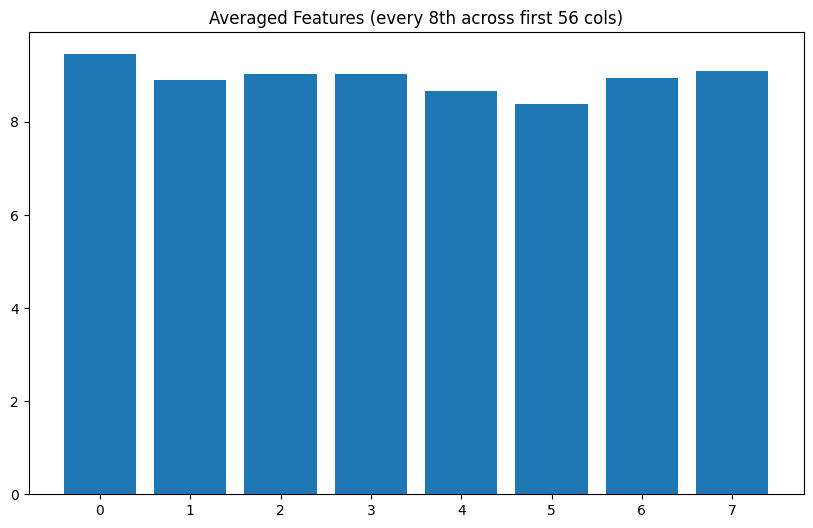

In [6]:
# average the first 56 features into 8 features by taking the mean of every 8th feature
# For each i in 0..7 we take columns [i, i+8, i+16, ..., i+48] (7 columns) and compute the per-sample mean
# Use explicit slicing with step=8 for clarity and safety
X_train_arr = X_train.iloc[:, :56].values
X_test_arr  = X_test.iloc[:, :56].values
X_train_avg = np.column_stack([X_train_arr[:, i:56:8].mean(axis=1) for i in range(8)])
X_test_avg  = np.column_stack([X_test_arr[:, i:56:8].mean(axis=1)  for i in range(8)])

# Plot the averaged features
plt.figure(figsize=(10, 6))
plt.bar(range(X_train_avg.shape[1]), X_train_avg.mean(axis=0))
plt.title('Averaged Features (every 8th across first 56 cols)')
plt.show()

In [7]:
# save the model using joblib
import joblib
joblib.dump(clf, 'svm_model_seba.pkl')

['svm_model_seba.pkl']

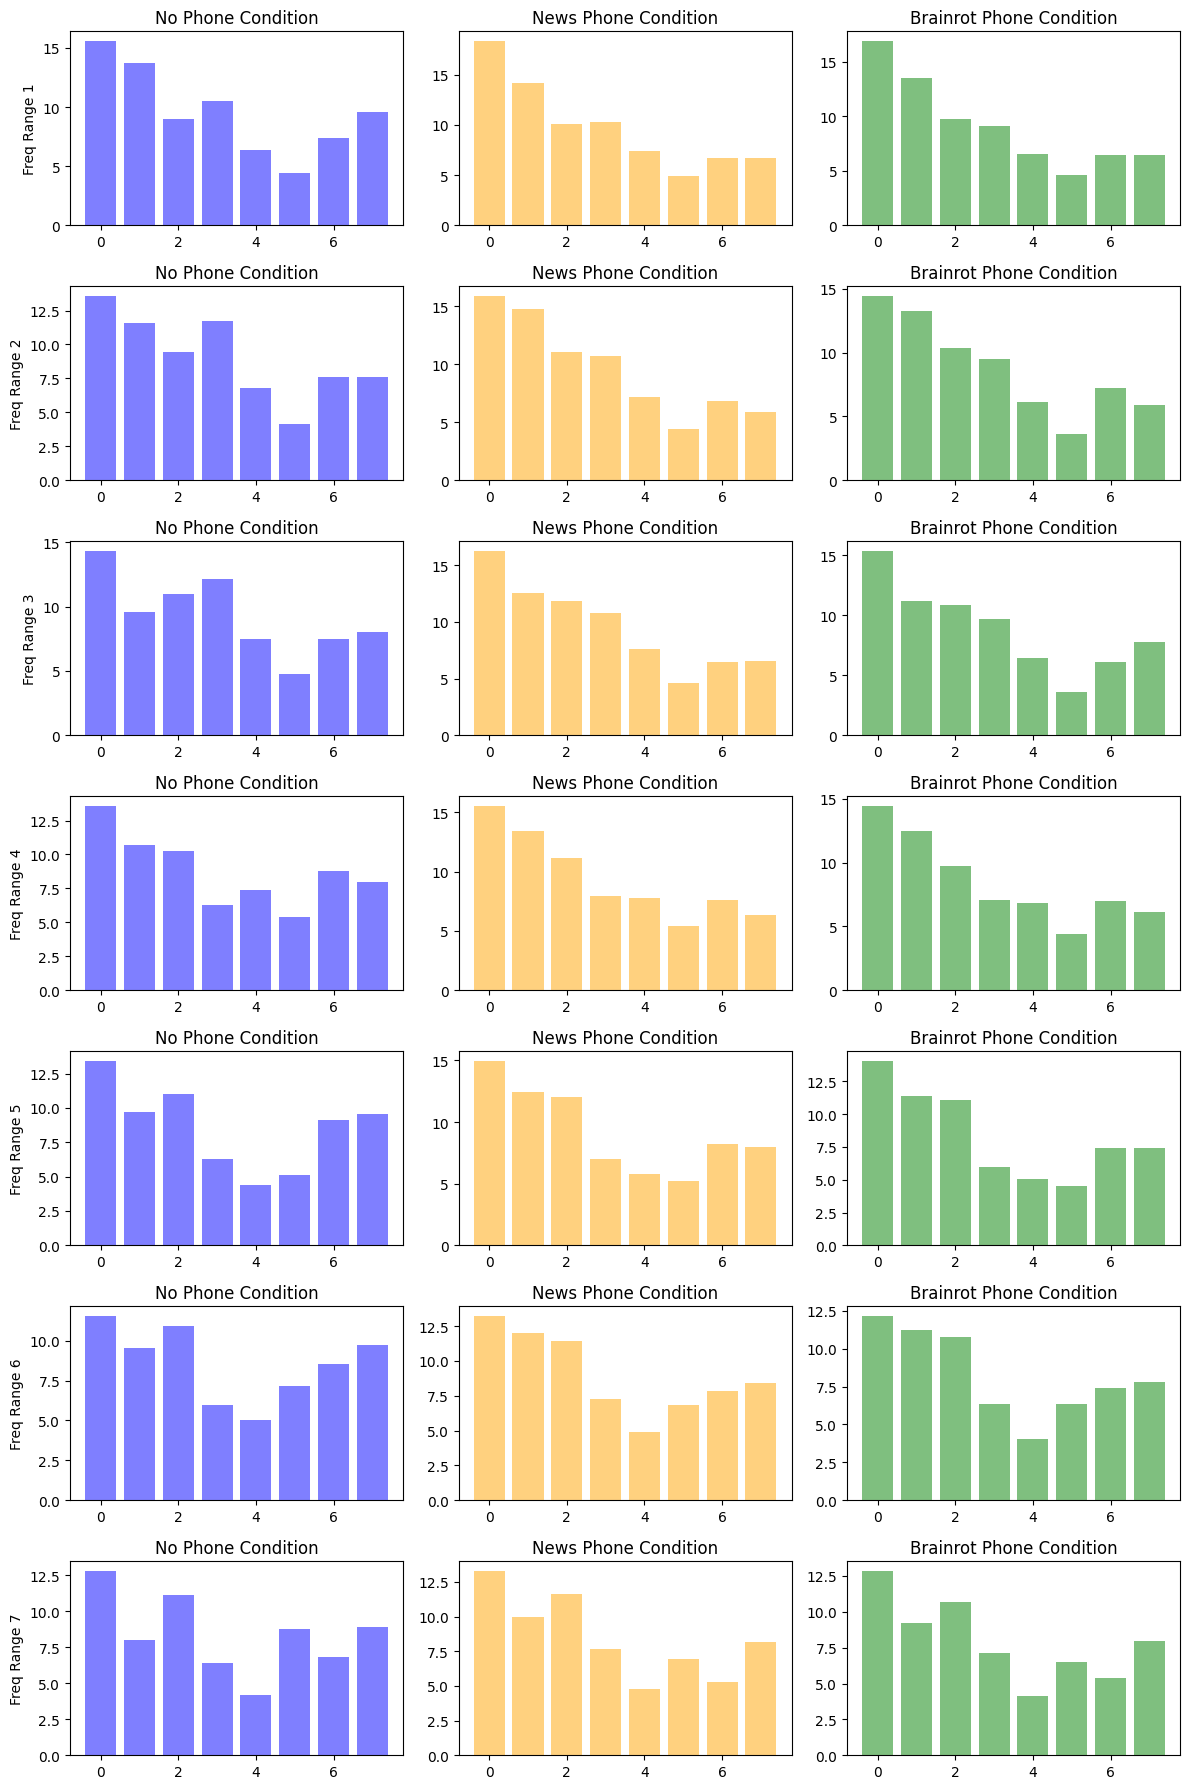

In [8]:
# plot 7 freq ranges x 3 conditions; each freq range has 8 channels in columns 0..55 (56 columns)
fig, axs = plt.subplots(7, 3, figsize=(12, 18))
conditions = ['No Phone', 'News Phone', 'Brainrot Phone']
n_freq = 7
n_channels = 8

for channel in range(n_channels):
    for freq in range(n_freq):
        # take the average over all the samples
        nophone_avg = data_nophone.iloc[:, channel * n_freq + freq].mean()
        news_avg = data_news.iloc[:, channel * n_freq + freq].mean()
        brainrot_avg = data_brainrot.iloc[:, channel * n_freq + freq].mean()
        # show the averaged values per channel in a bar plot
        axs[freq, 0].bar(channel, nophone_avg, color='blue', alpha=0.5)
        axs[freq, 1].bar(channel, news_avg, color='orange', alpha=0.5)
        axs[freq, 2].bar(channel, brainrot_avg, color='green', alpha=0.5)
        axs[freq, 0].set_title('No Phone Condition')
        axs[freq, 1].set_title('News Phone Condition')
        axs[freq, 2].set_title('Brainrot Phone Condition')
        axs[freq, 0].set_ylabel(f'Freq Range {freq+1}')
plt.tight_layout()
plt.show()

In [ ]:
# instead loop over the channels
data_channels = data.iloc[:, :56].values.reshape(data.shape[0], 8, 7)  # shape (n_samples, 8 channels, 7 freq ranges)

In [51]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

# visualize the a sample of the data using matplotlib and color by label
DecisionBoundaryDisplay.from_estimator(
    clf,
    X_train.iloc[:, :2],
    response_method="predict",
    xlabel="Feature 1",
    ylabel="Feature 2",
)
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train, edgecolors='k')
plt.show()

ValueError: X has 2 features, but SVC is expecting 70 features as input.

In [ ]:
# visualize the a sample of the data using matplotlib and color by label
import matplotlib.pyplot as plt


In [ ]:
# First create random data for testing
# The real data is 8 channel EEG data which is sampled at 0.5 second intervals and is turned into a power spectral density (PSD) representation
# For simplicity we will create random data with the same shape as the real data. There are two classes: brainrot (1) and attention (0)
num_samples = 1000
time_steps = 20  # e.g., 10 seconds of data at 0.5 second intervals
num_features = 8  # 8 EEG channels
X_br = np.random.rand(num_samples, time_steps, num_features)
y_br = np.random.randint(2, size=(num_samples, 1))  # binary labels

X_attend = np.random.rand(num_samples, time_steps, num_features)
y_attend = np.random.randint(2, size=(num_samples, 1))  # binary labels

# Concatenate the two classes along the sample dimension -> X will be shape (n_samples, time_steps, num_features)
X = np.concatenate((X_br, X_attend), axis=0)
# Ensure labels are 1D (scikit-learn expects (n_samples,) for y)
y = np.concatenate((y_br, y_attend), axis=0).ravel()

# For classical ML (SVM) we need a 2D feature matrix: flatten time and channel dims into a single feature vector per sample
X_flat = X.reshape((X.shape[0], -1))  # (n_samples, time_steps * num_features)

# Split using the flattened features
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=42)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [29]:
# Train the SVM
clf = svm.SVC(kernel='linear')
clf.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [32]:
# Save the model
model_filename = 'svm_eeg_model.pkl'
import joblib
joblib.dump(clf, model_filename)

['svm_eeg_model.pkl']

In [33]:
# load the model and predict
loaded_clf = joblib.load(model_filename)
y_pred = loaded_clf.predict(X_test)

In [34]:
y_pred

array([0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1,

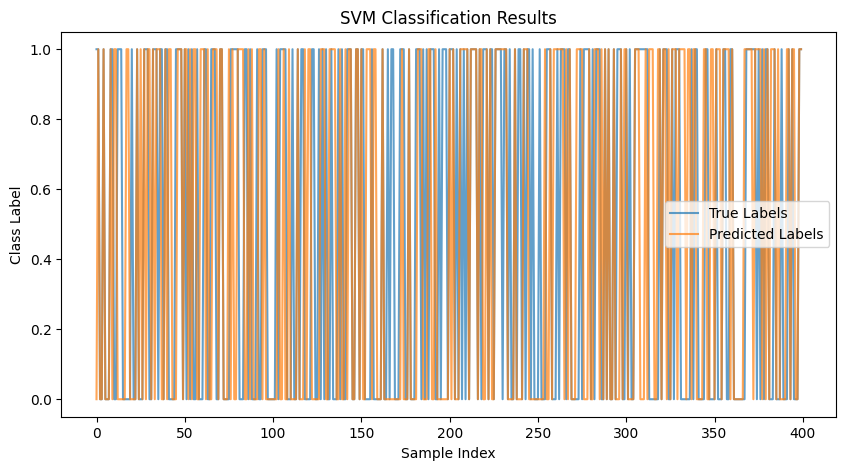

In [31]:
# Predict and evaluate
y_pred = clf.predict(X_test)
# plot the prediction results
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_test, label='True Labels', alpha=0.7)
plt.plot(y_pred, label='Predicted Labels', alpha=0.7)
plt.legend()
plt.title('SVM Classification Results')
plt.xlabel('Sample Index')
plt.ylabel('Class Label')
plt.show()

In [27]:
# Make predictions
y_pred = clf.predict(X_test)
# Evaluate the model
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[119  89]
 [ 92 100]]
              precision    recall  f1-score   support

           0       0.56      0.57      0.57       208
           1       0.53      0.52      0.52       192

    accuracy                           0.55       400
   macro avg       0.55      0.55      0.55       400
weighted avg       0.55      0.55      0.55       400



In [28]:
# Create an LSTM model to classify brainrot vs attention
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# For LSTM we want a 3D array: (n_samples, time_steps, num_features).
# The variable X above is still the original 3D array, so we can use it directly.
X_reshaped = X  # already (n_samples, time_steps, num_features)
# Ensure y is 1D (we set y = ... .ravel() earlier)
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_reshaped, y, test_size=0.2, random_state=42)

# Build the LSTM model
model = Sequential()
model.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the LSTM model
model.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=32, validation_data=(X_test_lstm, y_test_lstm))

# Evaluate the LSTM model
loss, accuracy = model.evaluate(X_test_lstm, y_test_lstm)
print(f'LSTM Test Accuracy: {accuracy}')

/opt/miniconda3/envs/neurospark/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.4831 - loss: 0.6979 - val_accuracy: 0.5025 - val_loss: 0.6934
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.4831 - loss: 0.6979 - val_accuracy: 0.5025 - val_loss: 0.6934
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4975 - loss: 0.6937 - val_accuracy: 0.4475 - val_loss: 0.6937
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4975 - loss: 0.6937 - val_accuracy: 0.4475 - val_loss: 0.6937
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5013 - loss: 0.6941 - val_accuracy: 0.4750 - val_loss: 0.6958
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5013 - loss: 0.6941 - val_accuracy: 0.4750 - val_loss: 0.6958
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5025 - loss: 0.6940 - val_accuracy: 0.5175 - val_loss: 0.6935
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5025 - loss: 0.6940 - val_accuracy: 0.5175 - v